# Tema : Modelos ARIMA
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

## Ejercicio 1. Pronostico del PIB de Colombia.

- Usando los datos del Banco Mundial, estime un modelo ARIMA válido acorde a la teoría entre 1960-2024. Finalmente, realice el pronostico del PIB de Colombia para los próximos 5 años.



In [140]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')


# Descargar los datos del Banco Mundial

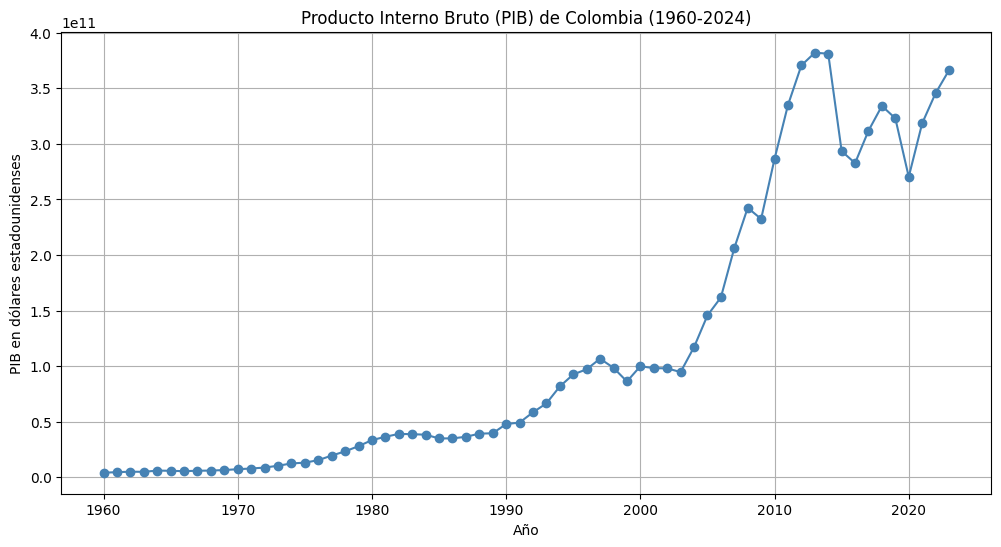

In [141]:
data = wb.data.DataFrame(series='NY.GDP.MKTP.CD', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data = data.set_index('year')
pib_col = data['pib']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data.index, pib_col, marker='o', color='steelblue')
ax.set_title('Producto Interno Bruto (PIB) de Colombia (1960-2024)')
ax.set_xlabel('Año')
ax.set_ylabel('PIB en dólares estadounidenses')
ax.grid()
plt.show()


## Verificar estacionaridad de la serie original

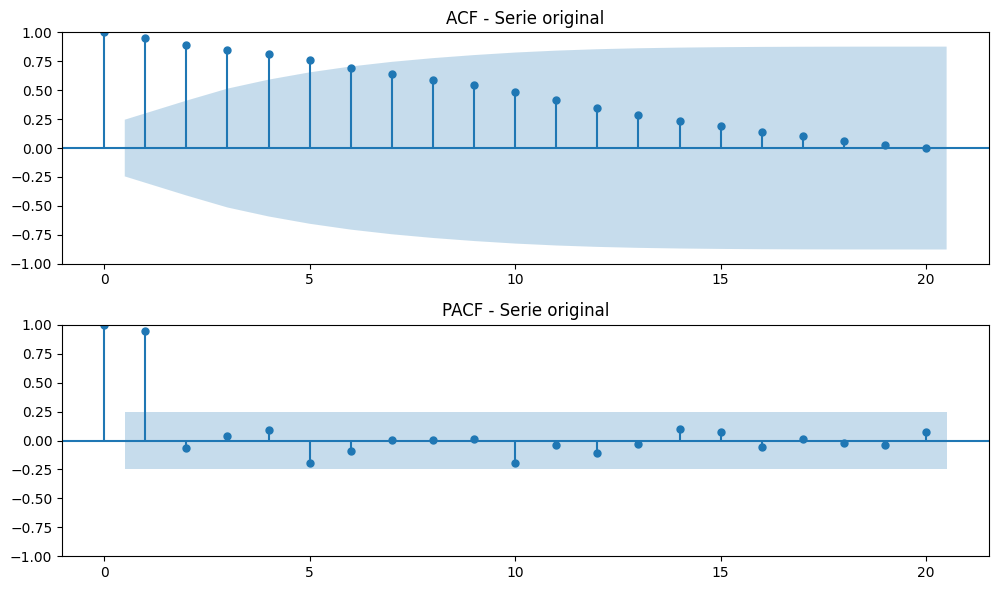

In [142]:
# Graficar la funcion de ACF y PACF
def graficar_autocorrelacion(data, title, maxlag = 20):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(data, lags=maxlag, ax=axes[0], title=f'ACF - {title}')
    plot_pacf(data, lags=maxlag, ax=axes[1], title=f'PACF - {title}')
    plt.tight_layout()
    plt.show()

graficar_autocorrelacion(pib_col, title= "Serie original")

In [143]:
def test_autocorrelacion(datos, n_lags=20):
    # Ljung-Box (Prueba global)
    lb_test        = acorr_ljungbox(datos, lags=n_lags, return_df=True)
    min_p_value    = lb_test['lb_pvalue'].min()
    lb_stat        = lb_test.loc[lb_test['lb_pvalue'] == min_p_value, 'lb_stat'].iloc[0]

    # Durbin-Watson (Autocorrelación de primer orden)
    dw_stat = durbin_watson(datos)

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Durbin-Watson", f"Ljung-Box (hasta lag {n_lags})"],
        'Estadístico' : [round(dw_stat, 4), round(lb_stat, 4)],
        'P-valor'     : [None, round(min_p_value, 4)]
    })

    # Conclusiones
    dw_conclu = (
        "Sin autocorrelación" if 1.5 < dw_stat < 2.5 else
        "Autocorrelación positiva" if dw_stat < 1.5 else
        "Autocorrelación negativa"
    )
    lb_conclu = "Sin autocorrelación" if min_p_value > 0.05 else "Autocorrelación detectada"
    tab_test['Conclusión'] = [dw_conclu, lb_conclu]

    print("=" * 80)
    print("PRUEBA DE LJUNG-BOX Y DURBIN-WATSON")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_autocorrelacion(pib_col, n_lags=20)

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       0.0152      NaN   Autocorrelación positiva
1  Ljung-Box (hasta lag 20)     418.2162      0.0  Autocorrelación detectada


In [144]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(pib_col)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)       2.7717     1.00           No
1                           Prueba KPSS       0.9984     0.01           No


## Integración de la serie para estacionaridad

- Para integrar una serie con el fin de estabilizar la media y la varianza sacamos su primera diferencia

1. $E[Y_t] = \mu$ (constante) $\forall t$
2. $Var(Y_t) = \sigma^2$ (constante) $\forall t$
3. $Cov(Y_t, Y_{t+k}) = \gamma_k$ (solo depende del rezago $k$)

$$
\Delta y_t = y_t - y_{t-1}
$$

## Transformaciones usuales en las series económicas 

- Es usual transformar la series económicas en términos de crecimiento porcentual aplicando logaritmos y posterior tomar su primera diferencia que es equivalente a incremento porcentual.
- Como vimos en la transformación de Box-Cox (λ=0), el logaritmo ayuda a linealizar funciones exponenciales y varianza creciente.

$$
\Delta \log{y_t} = \log{y_t} - \log{y_{t-1}} = \log{\frac{y_t}{y_{t-1}}} \sim \%\Delta y_t
$$

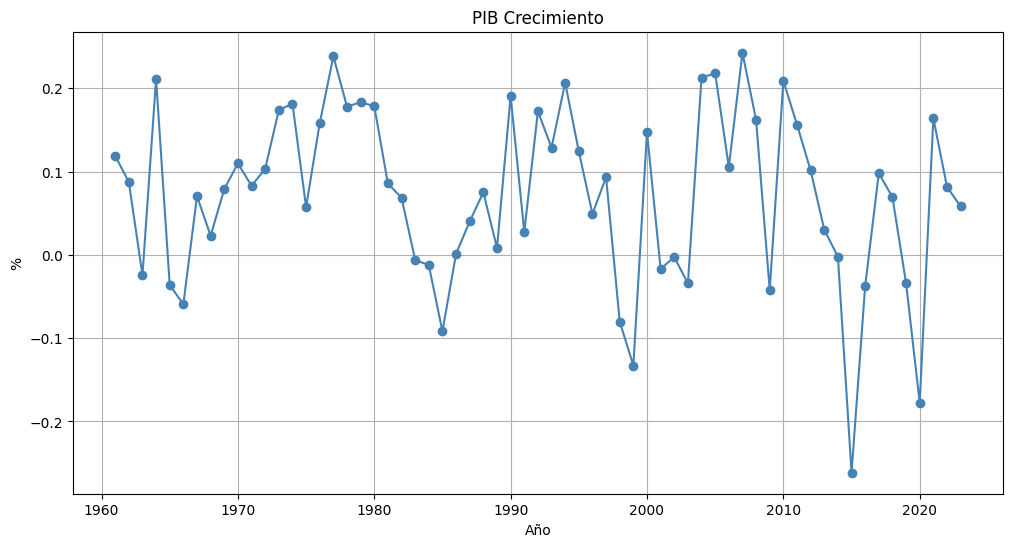

In [145]:
# Primera diferencia de la serie integrada de orden 1
pib_diff = pib_col.diff().dropna()

# Tomamos el logaritmo y la primera diferencia. Esto transforma la serie en tasas de crecimiento
pib_log = np.log(pib_col)
pib_crecimiento = pib_log.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pib_crecimiento, marker='o', color='steelblue')
ax.set_title('PIB Crecimiento')
ax.set_xlabel('Año')
ax.set_ylabel('%')
ax.grid()
plt.show()


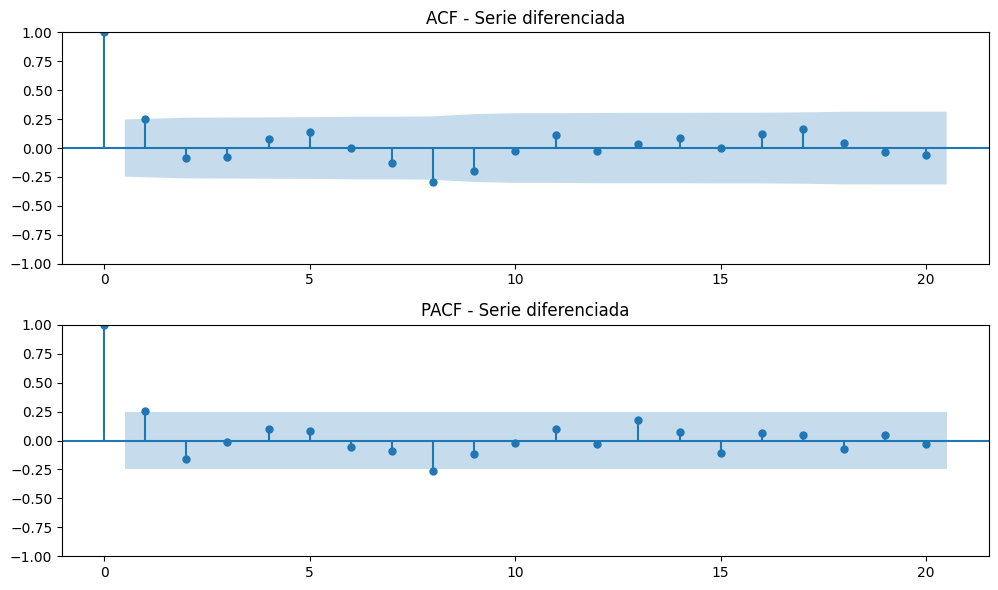

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -5.9457      0.0           Sí
1                           Prueba KPSS       0.2410      0.1           Sí


In [146]:
# Graficar la funcion de ACF y PACF de la serie diferenciada
graficar_autocorrelacion(pib_diff, title="Serie diferenciada")

# Test estacionariedad
test_estacionariedad(pib_diff)

## Estimación modelos ARIMA

In [147]:
# ARIMA(1, 1, 0)
m_arima110 = ARIMA(pib_crecimiento, order = (1, 0, 0)).fit()
print(m_arima110.summary())

# guardar modelos estimados
modelos = {}
modelos["ARIMA(1, 1, 0)"] = m_arima110

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  55.505
Date:                Mon, 02 Mar 2026   AIC                           -105.010
Time:                        00:16:09   BIC                            -98.581
Sample:                             0   HQIC                          -102.481
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0718      0.020      3.657      0.000       0.033       0.110
ar.L1          0.2795      0.128      2.187      0.029       0.029       0.530
sigma2         0.0100      0.002      5.751      0.0

In [148]:
# ARIMA(0, 1, 1)
m_arima011 = ARIMA(pib_crecimiento, order = (0, 0, 1)).fit()
print(m_arima011.summary())

# guardar
modelos["ARIMA(0, 1, 1)"] = m_arima011

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(0, 0, 1)   Log Likelihood                  55.215
Date:                Mon, 02 Mar 2026   AIC                           -104.430
Time:                        00:16:09   BIC                            -98.000
Sample:                             0   HQIC                          -101.901
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0717      0.018      4.070      0.000       0.037       0.106
ma.L1          0.2578      0.131      1.972      0.049       0.002       0.514
sigma2         0.0101      0.002      5.765      0.0

In [149]:
# ARIMA(1, 1, 1)
m_arima111 = ARIMA(pib_crecimiento, order = (1, 0, 1)).fit()
print(m_arima111.summary())

# guardar
modelos["ARIMA(1, 1, 1)"] = m_arima111

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  55.756
Date:                Mon, 02 Mar 2026   AIC                           -103.512
Time:                        00:16:09   BIC                            -94.939
Sample:                             0   HQIC                          -100.140
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0719      0.023      3.130      0.002       0.027       0.117
ar.L1          0.5701      0.413      1.379      0.168      -0.240       1.380
ma.L1         -0.3204      0.469     -0.683      0.4

In [150]:
# Auto-ARIMA encuentra los parámetros óptimos automáticamente
m_autoARIMA = auto_arima(pib_crecimiento, 
                         seasonal=False,      # No seasonal
                         stepwise=True,       # Búsqueda por pasos
                         trace=True,          # Mostrar progreso
                         error_action='ignore',
                         suppress_warnings=True,
                         start_p=0, start_q=0, max_p=5, max_q=5, d=0)

print("Auto-ARIMA")
print(m_autoARIMA.summary())
print(f'Parámetros óptimos: ARIMA{m_autoARIMA.order}')

modelos["auto-ARIMA"] = ARIMA(pib_crecimiento, order = (1, 0, 0), trend="c").fit()


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-79.573, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-96.161, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-90.520, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-96.649, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-98.066, Time=0.04 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=-96.221, Time=0.24 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-96.190, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-97.191, Time=0.06 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-94.273, Time=0.12 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-102.353, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-103.241, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-105.010, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-101.815, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-103.512, Time=0.09 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=

In [151]:
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

comparar_modelos_arima(modelos)

mejor_modelo = modelos['ARIMA(1, 1, 0)']

COMPARACIÓN DE MODELOS ARIMA
                 Modelo         AIC        AICc        BIC    Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                         
1        ARIMA(1, 1, 0) -105.010140 -104.603360 -98.580736  55.505070  0.010042  0.100211  0.078546       3   63
2            auto-ARIMA -105.010140 -104.603360 -98.580736  55.505070  0.010042  0.100211  0.078546       3   63
3        ARIMA(0, 1, 1) -104.429871 -104.023091 -98.000467  55.214935  0.010137  0.100681  0.078878       3   63
4        ARIMA(1, 1, 1) -103.511512 -102.821857 -94.938973  55.755756  0.009960  0.099802  0.078475       4   63
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): ARIMA(1, 1, 0)  →  AICc: -104.60336018256804


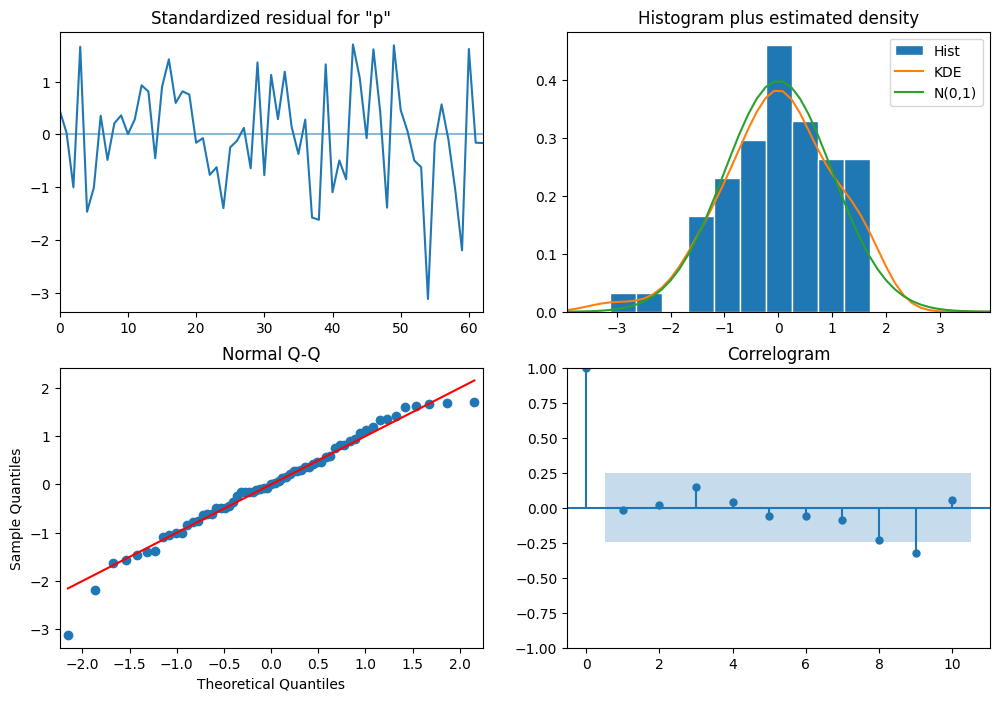

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       2.0231      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)      26.6033   0.0641  Sin autocorrelación


In [152]:
# Verificar ruido blanco
# Diagnostico del modelo
def plot_diagnostics(modelo, n_lags=10):
    if not "statsmodels" in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")

    # Diagnóstico
    modelo.plot_diagnostics(figsize=(12,8))
    plt.show()

    # test_autocorrelacion
    test_autocorrelacion(modelo.resid, n_lags=n_lags)

# Ejecución de la función
plot_diagnostics(modelo = mejor_modelo, n_lags=20)


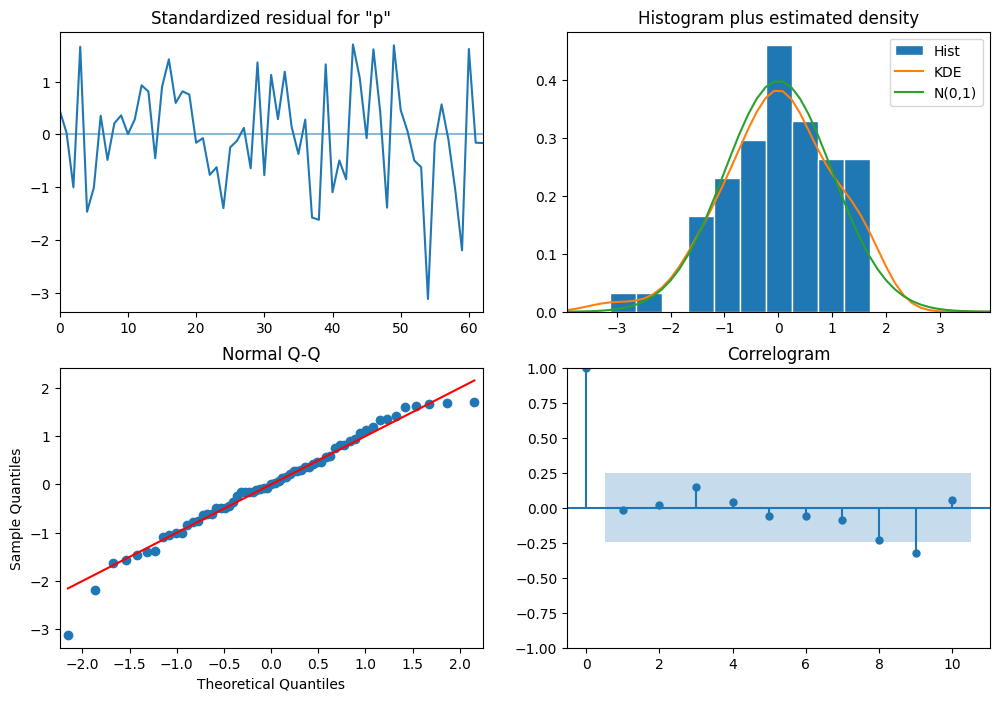

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       2.0231      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)      26.6033   0.0641  Sin autocorrelación


In [153]:
# Verificar ruido blanco
plot_diagnostics(modelo = mejor_modelo, n_lags=20)

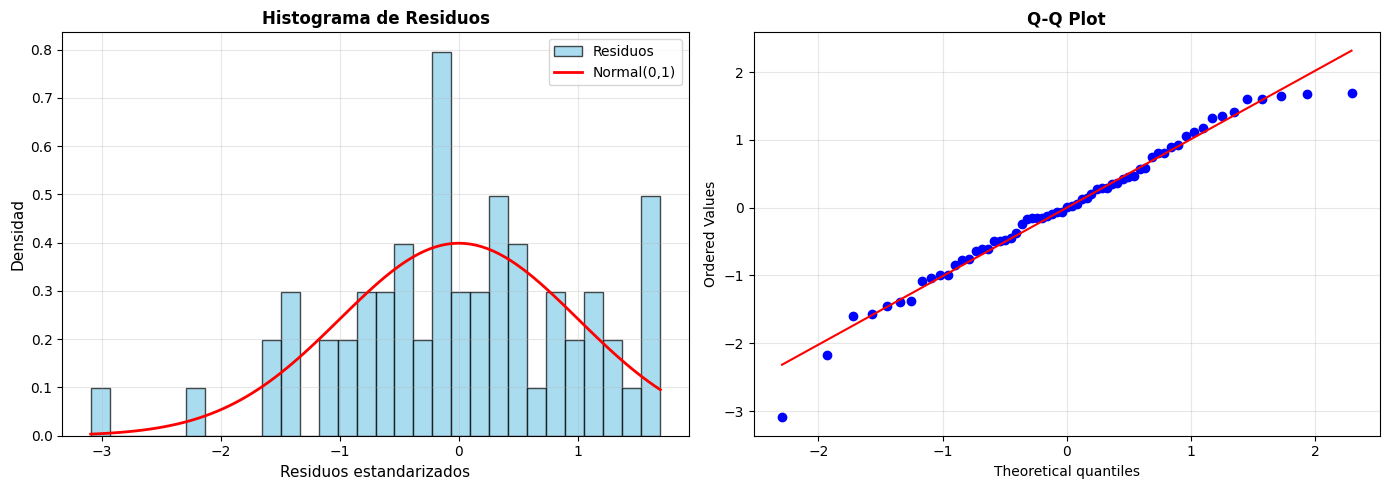

,test,estadistico,p_valor
0,Shapiro-Wilk,0.9771,0.2869
1,Jarque-Bera,1.9797,0.3716
2,Kolmogorov-Smirnov,0.0709,0.8873
3,Asimetría,-0.4128,NaN
4,Curtosis,3.2695,NaN


In [154]:
# Normalidad de los residuos
def check_normalidad(modelo):    
    # Verificación del tipo de modelo
    if 'statsmodels' not in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")
    
    # Extraer residuos estandarizados
    resid = modelo.resid
    resid_std = (resid - resid.mean()) / resid.std()
    
    # Gráfico 1: Histograma con curva normal
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1 = axes[0]
    ax1.hist(resid_std, bins=30, density=True, alpha=0.7, 
             color='skyblue', edgecolor='black', label='Residuos')
    
    # Superponer curva normal teórica
    x = np.linspace(resid_std.min(), resid_std.max(), 100)
    ax1.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, 
             label='Normal(0,1)')
    
    ax1.set_xlabel('Residuos estandarizados', fontsize=11)
    ax1.set_ylabel('Densidad', fontsize=11)
    ax1.set_title('Histograma de Residuos', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Q-Q Plot
    ax2 = axes[1]
    stats.probplot(resid_std, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Prueba de Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(resid)
    
    # Prueba de Jarque-Bera
    jb_stat, jb_p, skew, kurtosis = jarque_bera(resid)
    
    # Prueba de Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(resid_std, 'norm')
    
    # Resultados
    results = {
        'test' : ['Shapiro-Wilk', 'Jarque-Bera', 'Kolmogorov-Smirnov', 'Asimetría', 'Curtosis'],
        'estadistico' : [shapiro_stat, jb_stat, ks_stat, skew, kurtosis],
        'p_valor' : [shapiro_p, jb_p, ks_p, None, None]
    }
    tab_test = pd.DataFrame(results)
    tab_test[["estadistico", "p_valor"]] = tab_test[["estadistico", "p_valor"]].apply(lambda x: round(x, 4))
    return tab_test
    

check_normalidad(modelo = mejor_modelo)

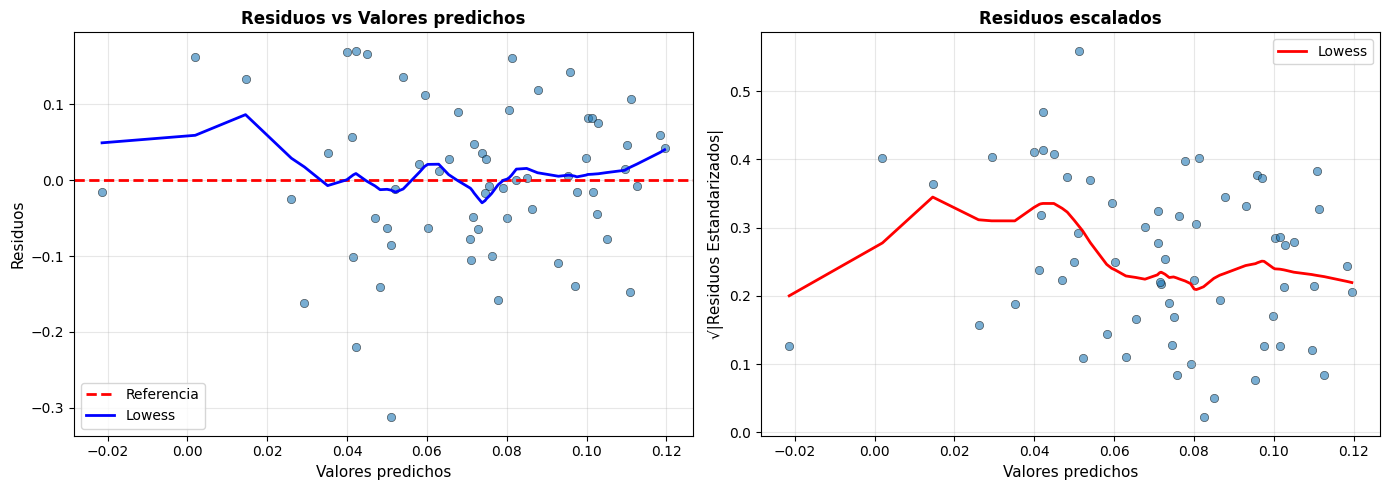

In [155]:
def check_homocedasticidad(modelo):
    # Verificación del tipo de modelo
    if 'statsmodels' not in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")
    
    # Extraer residuos y valores predichos del modelo
    resid = modelo.resid
    fitted_values = modelo.fittedvalues
    resid_abs = np.abs(resid)
    resid_sqrt = np.sqrt(resid_abs)
    
    # Crear figuras
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Residuos vs Valores ajustados
    ax1 = axes[0]
    ax1.scatter(fitted_values, resid, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Referencia')
    
    # Línea de tendencia
    smoothed = lowess(resid, fitted_values, frac=0.3)
    ax1.plot(smoothed[:, 0], smoothed[:, 1], color='blue', linewidth=2, label='Lowess')
    
    ax1.set_xlabel('Valores predichos', fontsize=11)
    ax1.set_ylabel('Residuos', fontsize=11)
    ax1.set_title('Residuos vs Valores predichos', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Residuos Estandarizados
    ax2 = axes[1]
    ax2.scatter(fitted_values, resid_sqrt, alpha=0.6, edgecolors='k', linewidth=0.5)
    
    # Línea de tendencia
    smoothed2 = lowess(resid_sqrt, fitted_values, frac=0.3)
    ax2.plot(smoothed2[:, 0], smoothed2[:, 1], color='red', linewidth=2, label='Lowess')
    
    ax2.set_xlabel('Valores predichos', fontsize=11)
    ax2.set_ylabel('√|Residuos Estandarizados|', fontsize=11)
    ax2.set_title('Residuos escalados', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

check_homocedasticidad(modelo=mejor_modelo)

## Pronóstico mejor modelo modelo crecimiento PIB

Acorde al DANE En 2024p, el Producto Interno Bruto (PIB) presenta un crecimiento de 1,5% respecto a 2023. El modelo pronosticó 0,68% de incremento para 2024 respecto a 2023.
https://www.dane.gov.co/index.php/estadisticas-por-tema/cuentas-nacionales/cuentas-nacionales-anuales

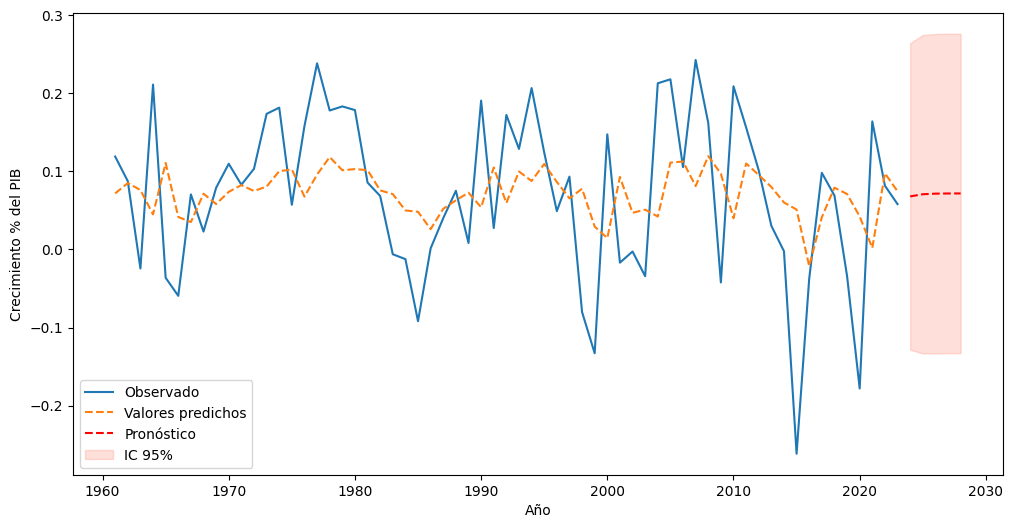

      Pronóstico  IC Inferior  IC Superior
Año                                       
2024    0.067946    -0.128430     0.264322
2025    0.070711    -0.133192     0.274613
2026    0.071483    -0.132996     0.275962
2027    0.071699    -0.132825     0.276223
2028    0.071760    -0.132768     0.276287


In [156]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_anio  = pib_crecimiento.index[-1]
anio_pronostico = range(ultimo_anio + 1, ultimo_anio + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_pib = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean = pronostico_pib.predicted_mean
pred_ci = pronostico_pib.conf_int()

# Alinear índice con la serie original
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
ax = pib_crecimiento.plot(label = "Observado")
plt.plot(mejor_modelo.fittedvalues.index, mejor_modelo.fittedvalues, label = "Valores predichos", linestyle = "--")
pred_mean.plot(ax = ax, label = "Pronóstico", linestyle = "--", color = "red")
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Año')
ax.set_ylabel('Crecimiento % del PIB')
ax.legend()
plt.show()

# Tabla de pronóstico 
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Año"
print(df_forecast.to_string())


## Pronostico en sus niveles del PIB

- Reversar la transformación logarítmico del crecimiento
$$
\Delta \log(PIB_t) = \log(PIB_t) - \log(PIB_{t-1})  \\
PIB_{t+h} = PIB_{t} * \exp^{\sum^{h}_{i=1}\Delta \log(PIB_t)}
$$


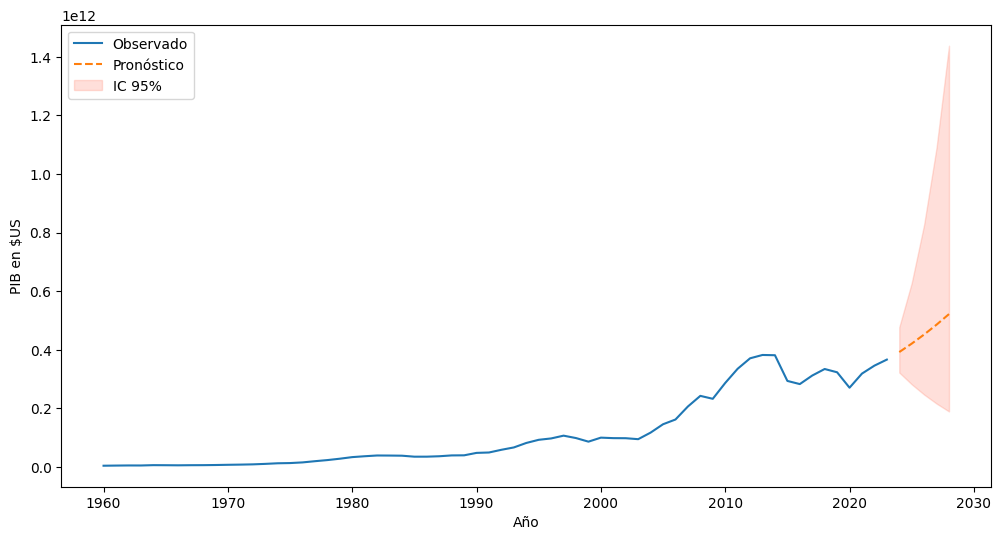

        Pronóstico   IC Inferior   IC Superior
Año                                           
2024  3.920448e+11  3.221444e+11  4.771126e+11
2025  4.207702e+11  2.819720e+11  6.278905e+11
2026  4.519493e+11  2.468577e+11  8.274331e+11
2027  4.855438e+11  2.161531e+11  1.090675e+12
2028  5.216668e+11  1.892785e+11  1.437756e+12


In [157]:
# Revertir log-diferencia a niveles
ultimo_pib_nivel = pib_col.iloc[-1]

pred_niveles     = ultimo_pib_nivel * np.exp(pred_mean.cumsum())
pred_ci_niveles  = pd.DataFrame({
    "lower": ultimo_pib_nivel * np.exp(pred_ci.iloc[:, 0].cumsum()),
    "upper": ultimo_pib_nivel * np.exp(pred_ci.iloc[:, 1].cumsum())
}, index=pred_mean.index)

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
ax = pib_col.plot(label = "Observado")
pred_niveles.plot(ax = ax, label = "Pronóstico", linestyle = "--")
ax.fill_between(
    pred_ci_niveles.index,
    pred_ci_niveles["lower"],
    pred_ci_niveles["upper"],
    color="tomato", alpha=0.2, label="IC 95%"
)
ax.set_xlabel('Año')
ax.set_ylabel('PIB en $US')
ax.legend()
plt.show()

# Tabla de pronóstico en niveles
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_niveles,
    "IC Inferior" : pred_ci_niveles["lower"],
    "IC Superior" : pred_ci_niveles["upper"],
})
df_forecast.index.name = "Año"
print(df_forecast.to_string())
